The aim of this notebook is to explore the minimum viable scale consisting of two common motor inhibitory(or challenge) scale items: hand immobile/heavy and hand rigid/stiff over various datasets. Figures of merit are pearson's (r), variance explained (r^2), and Cronbach alpha.

The datasets used:

Phenomenological Control Scale -

- df1 - PCS_norms_first_test_data.csv - https://osf.io/et85n
- df2 - PCS_VVIQ_raw.xlsx - https://osf.io/aeyhw/
- df5 - vEAR and PC data.csv - https://osf.io/a2skp/

SWASH Scale -


- df3 - SWASHPAPERDATA.csv - https://osf.io/wujk8/

PCS and SWASH have the same items and order,


1. Hand lowering
2. Moving hands together
3. Mosquito hallucination
4. Taste experience
5. Arm rigidity
6. Arm immobilization
7. Music hallucination
8. Negative visual hallucination
9. Amnesia
10. Post-hypnotic suggestion




Harvard Scale A -

- df4 - Tehrune Dimensional-data.csv -  osf.io/jfmc4
```
direct ideomotor (HGSHS:A items 1, 2, 3, 7), inhibitory ideomotor (items 4, 5, 6, 8, 10), cognitive-perceptual (items
9, 11), and posthypnotic amnesia (item 12)
https://kclpure.kcl.ac.uk/ws/portalfiles/portal/177259643/Reshetnikov_Terhune_2022.pdf#page=5.41
```

1. Head falling
2. Eye closure
3. Hand lowering
4. Arm immobilization
5. Finger lock
6. Arm rigidity
7. Hands moving together
8. Communication inhibition
9. Experiencing of fly
10. Eye catalepsy
11. Post-hypnotic suggestion
12. Amnesia


In [3]:
!python -m pip install pandas numpy scipy matplotlib scikit-learn openpyxl pingouin
#takes ages to install if you don't have these, get some tea
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import sklearn
import pingouin

# Load the first dataset (PCS norms first test data)
df1 = pd.read_csv('PCS_norms_first_test_data.csv')
df1


[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pandas-2.2.3-cp310-cp310-win_amd64.whl (11.6 MB)
  Using cached matplotlib-3.10.1-cp310-cp310-win_amd64.whl (8.1 MB)
  Using cached scikit_learn-1.6.1-cp310-cp310-win_amd64.whl (11.1 MB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
     ---------------------------------------- 0.0/204.4 kB ? eta -:--:--
     ------- ------------------------------- 41.0/204.4 kB 1.9 MB/s eta 0:00:01
     -------------------------------------- 204.4/204.4 kB 2.5 MB/s eta 0:00:00
  Using cached contourpy-1.3.1-cp310-cp310-win_amd64.whl (218 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
     ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/9.8 MB 10.0 MB/s eta 0:00:01
     ------- -------------------------------- 1.9/9.8 MB 19.6 MB/s eta 0:00:01
     ---------------- ----------------------- 4.1/9.8 MB 29.3 MB/s eta 0:00:01
     -------------------------- ------------- 6.4/9.8 MB 34.2 MB/s eta 0:00

,ParticipantNumber,Age,exclude,HandLoweringSubjectiveRating,HandsTogetherSubjectiveRating,MosquitoSubjectiveRating,TasteSubjectiveRating,ArmRigiditySubjectiveRating,ArmImmobilisationSubjectiveRating,MusicSubjectiveRating,...,SourSubRating,PostHypnoticSub1,PostHypnoticSub2,filter_$,Condition,HIGH,LOW,Gender,Subjective_scale_score_first_test,Objective_scale_score_first_test
0,2,21,0,5,4,4,3.0,5,3,3,...,3,5,2.0,1,1,1.0,0.0,0,3.72,7
1,330,19,0,5,5,4,4.5,5,4,0,...,4,5,0.0,1,1,1.0,0.0,0,3.55,6
2,245,19,0,5,5,4,3.5,5,5,0,...,4,4,5.0,1,1,1.0,0.0,0,3.40,6
3,123,20,0,4,5,2,3.5,5,4,0,...,4,5,2.0,1,1,1.0,0.0,0,3.37,7
4,90,19,0,5,4,2,4.5,5,4,2,...,4,3,3.0,1,1,1.0,0.0,0,3.25,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485,510,19,0,1,0,0,0.0,1,0,0,...,0,0,5.0,1,0,0.0,1.0,0,0.40,2
486,522,19,0,1,0,0,0.5,1,1,0,...,0,0,0.0,1,0,0.0,1.0,1,0.35,0
487,589,22,0,0,0,0,0.0,0,0,0,...,0,0,0.0,1,0,0.0,1.0,1,0.30,4
488,121,23,0,0,1,0,0.5,1,0,0,...,1,1,0.0,1,0,0.0,1.0,0,0.25,2


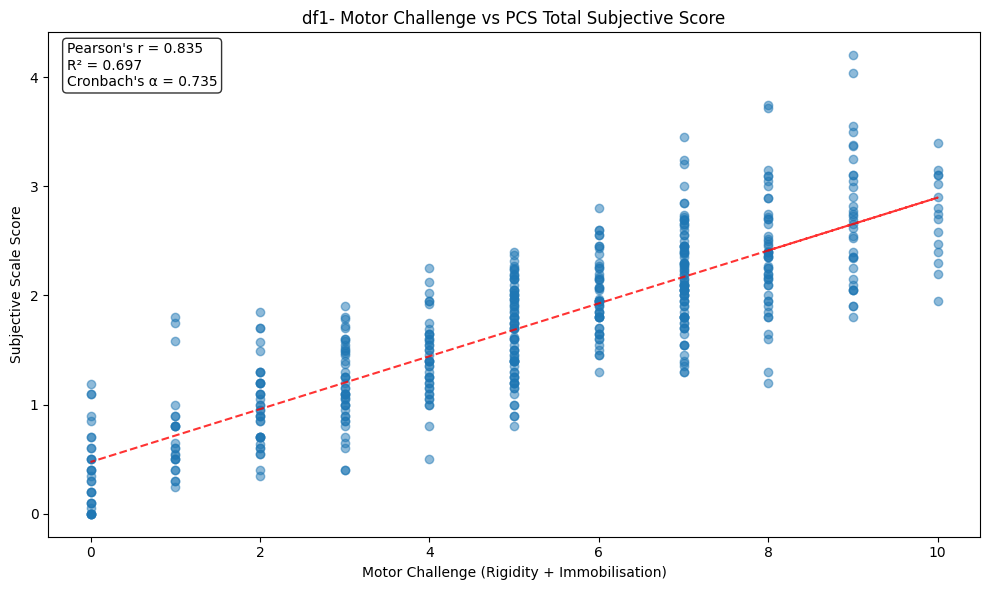


Detailed Statistics:
Pearson's r: 0.8349
R-squared: 0.6971
Cronbach's alpha: 0.7346


In [6]:
import pingouin as pg
import matplotlib.pyplot as plt
import numpy as np

# Calculate the sum of motor challenge ratings
df1['CombinedMotorRating'] = df1['ArmRigiditySubjectiveRating'] + df1['ArmImmobilisationSubjectiveRating']

# Calculate correlation using pingouin
correlation = pg.corr(df1['CombinedMotorRating'], 
                     df1['Subjective_scale_score_first_test'],
                     method='pearson')

# Extract r and calculate r-squared
pearson_r = correlation['r'].values[0]
r_squared = pearson_r**2

# Calculate Cronbach's alpha
items = df1[['ArmRigiditySubjectiveRating', 'ArmImmobilisationSubjectiveRating']]
alpha = pg.cronbach_alpha(items)
cronbach_alpha = alpha[0]  # Extract just the alpha value

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
plt.scatter(df1['CombinedMotorRating'], df1['Subjective_scale_score_first_test'], alpha=0.5)
plt.xlabel('Motor Challenge (Rigidity + Immobilisation)')
plt.ylabel('Subjective Scale Score')
plt.title('df1- Motor Challenge vs PCS Total Subjective Score')

# Add regression line
z = np.polyfit(df1['CombinedMotorRating'], df1['Subjective_scale_score_first_test'], 1)
p = np.poly1d(z)
plt.plot(df1['CombinedMotorRating'], p(df1['CombinedMotorRating']), "r--", alpha=0.8)

# Add summary statistics to plot
stats_text = f"Pearson's r = {pearson_r:.3f}\n"
stats_text += f"R² = {r_squared:.3f}\n"
stats_text += f"Cronbach's α = {cronbach_alpha:.3f}"

# Position the text in the upper left corner
plt.text(0.02, 0.98, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\nDetailed Statistics:")
print(f"Pearson's r: {pearson_r:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Cronbach's alpha: {cronbach_alpha:.4f}")

In [7]:
# Load the VVIQ dataset into df2
df2 = pd.read_excel('PCS_VVIQ_raw.xlsx')

# Display last 15 columns of df2
print(df2.columns[-15:])

Index(['vviq14', 'vviq15', 'vviq16', 'HandBecomesHeavy', 'MagneticHands',
       'Mosquito', 'SweetSubRating', 'SourSubRating', 'StiffArm',
       'HandAndArmHeavy', 'HappyBirthday', 'ColouredBalls', 'Amnesia',
       'PostHypnoticSub1', 'PostHypnoticSub2'],
      dtype='object')


Subjective total does not exist, motor challenge labels are HandAndArmHeavy and StiffArm

In [8]:
# create subjective total column by getting average of HandBecomesHeavy', 'MagneticHands',
#        'Mosquito', 'SweetSubRating', 'SourSubRating', 'StiffArm',
#        'HandAndArmHeavy', 'HappyBirthday', 'ColouredBalls', 'Amnesia',
#        'PostHypnoticSub1', 'PostHypnoticSub2'

# Calculate the average of specified columns and create a new 'SubjectiveTotal' column
df2['SubjectiveTotal'] = df2[['HandBecomesHeavy', 'MagneticHands', 'Mosquito', 'SweetSubRating', 'SourSubRating', 'StiffArm', 'HandAndArmHeavy', 'HappyBirthday', 'ColouredBalls', 'Amnesia', 'PostHypnoticSub1', 'PostHypnoticSub2']].mean(axis=1)


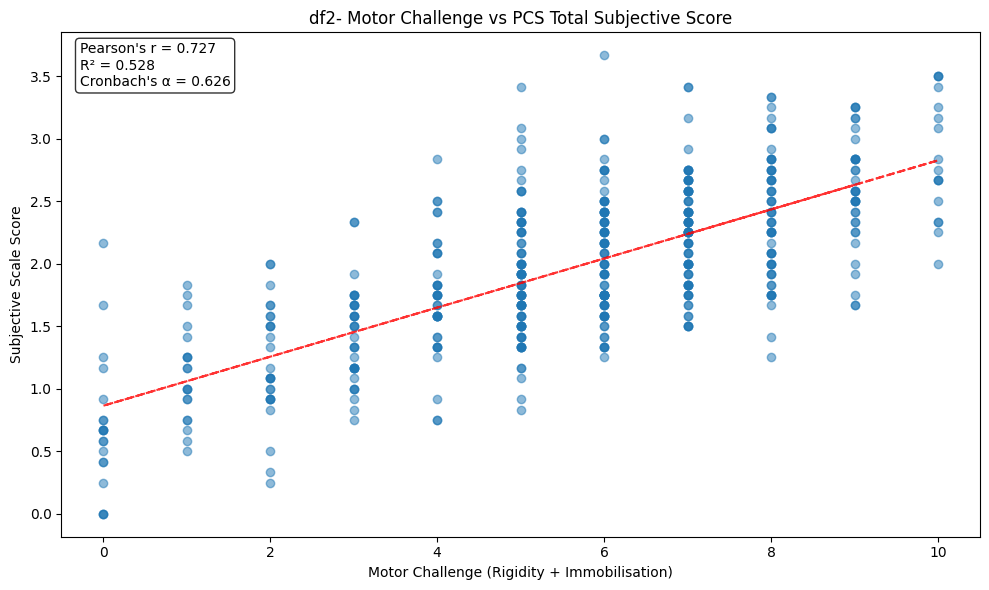


Detailed Statistics:
Pearson's r: 0.7266
R-squared: 0.5280
Cronbach's alpha: 0.6257


In [9]:
# Calculate the sum of 'HandAndArmHeavy' and 'StiffArm'
df2['CombinedMotorRating'] = df2['HandAndArmHeavy'] + df2['StiffArm']

# Calculate correlation using pingouin
correlation = pg.corr(df2['CombinedMotorRating'], 
                     df2['SubjectiveTotal'],
                     method='pearson')

# Extract r and calculate r-squared
pearson_r = correlation['r'].values[0]
r_squared = pearson_r**2

# Calculate Cronbach's alpha
items = df2[['HandAndArmHeavy', 'StiffArm']]
alpha = pg.cronbach_alpha(items)
cronbach_alpha = alpha[0]  # Extract just the alpha value

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
plt.scatter(df2['CombinedMotorRating'], df2['SubjectiveTotal'], alpha=0.5)
plt.xlabel('Motor Challenge (Rigidity + Immobilisation)')
plt.ylabel('Subjective Scale Score')
plt.title('df2- Motor Challenge vs PCS Total Subjective Score')

# Add regression line
z = np.polyfit(df2['CombinedMotorRating'], df2['SubjectiveTotal'], 1)
p = np.poly1d(z)
plt.plot(df2['CombinedMotorRating'], p(df2['CombinedMotorRating']), "r--", alpha=0.8)

# Add summary statistics to plot
stats_text = f"Pearson's r = {pearson_r:.3f}\n"
stats_text += f"R² = {r_squared:.3f}\n"
stats_text += f"Cronbach's α = {cronbach_alpha:.3f}"

# Position the text in the upper left corner
plt.text(0.02, 0.98, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\nDetailed Statistics:")
print(f"Pearson's r: {pearson_r:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Cronbach's alpha: {cronbach_alpha:.4f}")



In [12]:
# Load the Stroop depletion experiment 1 dataset
df3 = pd.read_csv('SWASHPAPERDATA.csv')

# Calculate the sum of motor challenge ratings (assuming similar column names)
# First, let's check the column names to make sure we're using the right ones
print("Available columns:")
print(df3.columns)



Available columns:
Index(['Booklet', 'UNIVERSITY', 'Participantnumber', 'Age', 'Sex',
       'Objectivescore', 'Objectivereturnscore', 'Subjectivescore',
       'Subjectivereturnscore', 'Inductionrating', 'Q1HANDLOWEROBB',
       'Q1HANDLOWERSUBJ', 'Q2MAGNETICOBJ', 'Q2MAGNETICSUBJ', 'Q3MOSQUITOOBJ',
       'Q3MOSQUITOSUBJ', 'Q4TASTEOBJ', 'TASTEMEAN', 'Q4TASTE1SUBJ',
       'Q4TASTE2SUBJ', 'Q5RIGIDITYOBJ', 'Q5RIGIDITYSUBJ', 'Q6IMMOBILEOBJ',
       'Q6IMMOBILESUBJ', 'Q7MUSICOBJ', 'Q7MUSICSUBJ', 'Q8BALLSOBJ',
       'Q8BALLSSUBJ', 'Q9AMNESIAOBJ', 'Q9AMNESIASUBJ', 'Q10PHSOBJ',
       'Q10PHSSUBJ1', 'Q10PHSSUBJ2', 'PHSSUBJECTIVEGEOMETRICMEAN'],
      dtype='object')


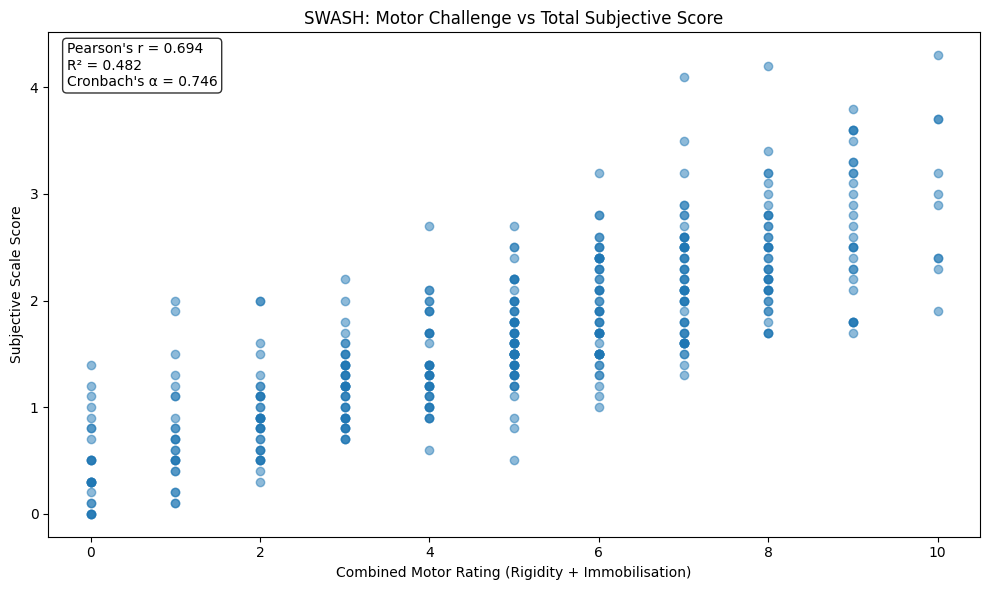


Detailed Statistics:
Pearson's r: 0.6943
R-squared: 0.4820
Cronbach's alpha: 0.7461


In [23]:
# Calculate combined motor rating and correlations
df3['CombinedMotorRating'] = df3['Q5RIGIDITYSUBJ'] + df3['Q6IMMOBILESUBJ']

# Calculate correlation using pingouin
correlation = pg.corr(df3['CombinedMotorRating'], 
                     df3['Subjectivereturnscore'],
                     method='pearson')

# Extract r and calculate r-squared
pearson_r = correlation['r'].values[0]
r_squared = pearson_r**2

# Calculate Cronbach's alpha
items = df3[['Q5RIGIDITYSUBJ', 'Q6IMMOBILESUBJ']]
alpha = pg.cronbach_alpha(items)
cronbach_alpha = alpha[0]  # Extract just the alpha value

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
plt.scatter(df3['CombinedMotorRating'], df3['Subjectivescore'], alpha=0.5)
plt.xlabel('Combined Motor Rating (Rigidity + Immobilisation)')
plt.ylabel('Subjective Scale Score')
plt.title('SWASH: Motor Challenge vs Total Subjective Score')


# Add summary statistics to plot
stats_text = f"Pearson's r = {pearson_r:.3f}\n"
stats_text += f"R² = {r_squared:.3f}\n"
stats_text += f"Cronbach's α = {cronbach_alpha:.3f}"

# Position the text in the upper left corner
plt.text(0.02, 0.98, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\nDetailed Statistics:")
print(f"Pearson's r: {pearson_r:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Cronbach's alpha: {cronbach_alpha:.4f}")

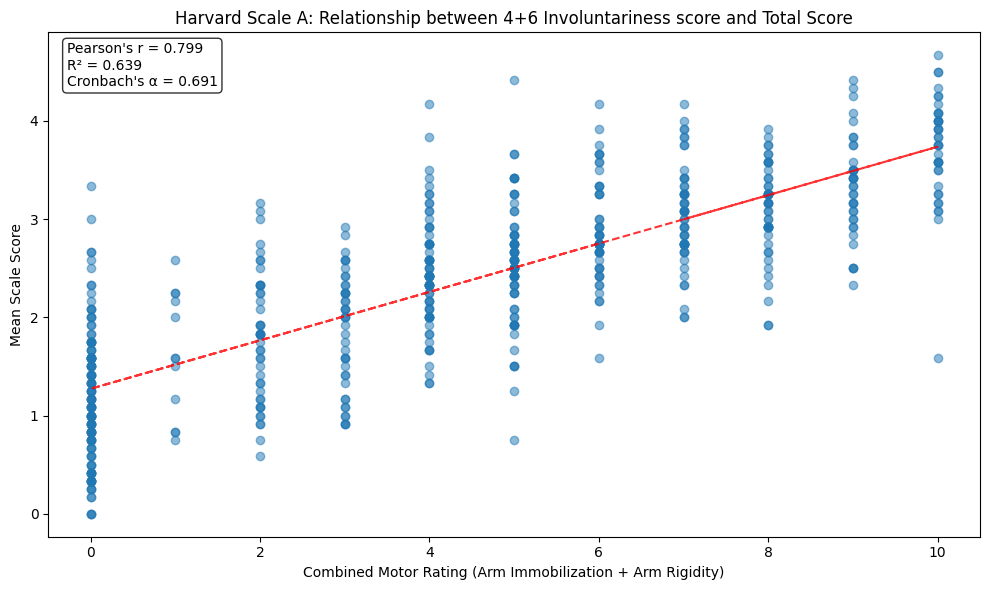


Detailed Statistics:
Pearson's r: 0.7994
R-squared: 0.6390
Cronbach's alpha: 0.6911


In [20]:
# Load the Terhune dataset
df4 = pd.read_csv('Tehrune Dimensional-data.csv')

# Calculate the sum of motor challenge ratings
# Items 4 (Arm immobilization) and 6 (Arm rigidity) from Harvard Scale A
df4['CombinedMotorRating'] = df4['INV.4'] + df4['INV.6']

# Calculate mean of all items for total score
# Items 1-12 as per the legend# Create a list of column names
inv_columns = [f'INV.{i}' for i in range(1, 13)]  # This creates ['INV.1', 'INV.2', ..., 'INV.12']

# Calculate mean using the list of columns
df4['SubjectiveTotal'] = df4[inv_columns].mean(axis=1)

# Calculate correlation using pingouin
correlation = pg.corr(df4['CombinedMotorRating'], 
                     df4['SubjectiveTotal'],
                     method='pearson')

# Extract r and calculate r-squared
pearson_r = correlation['r'].values[0]
r_squared = pearson_r**2

# Calculate Cronbach's alpha
items = df4[['INV.4', 'INV.6']]
alpha = pg.cronbach_alpha(items)
cronbach_alpha = alpha[0]  # Extract just the alpha value

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
plt.scatter(df4['CombinedMotorRating'], df4['SubjectiveTotal'], alpha=0.5)
plt.xlabel('Combined Motor Rating (Arm Immobilization + Arm Rigidity)')
plt.ylabel('Mean Scale Score')
plt.title('Harvard Scale A: Relationship between 4+6 Involuntariness score and Total Score')

# Add regression line
z = np.polyfit(df4['CombinedMotorRating'], df4['SubjectiveTotal'], 1)
p = np.poly1d(z)
plt.plot(df4['CombinedMotorRating'], p(df4['CombinedMotorRating']), "r--", alpha=0.8)

# Add summary statistics to plot
stats_text = f"Pearson's r = {pearson_r:.3f}\n"
stats_text += f"R² = {r_squared:.3f}\n"
stats_text += f"Cronbach's α = {cronbach_alpha:.3f}"

# Position the text in the upper left corner
plt.text(0.02, 0.98, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\nDetailed Statistics:")
print(f"Pearson's r: {pearson_r:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Cronbach's alpha: {cronbach_alpha:.4f}")

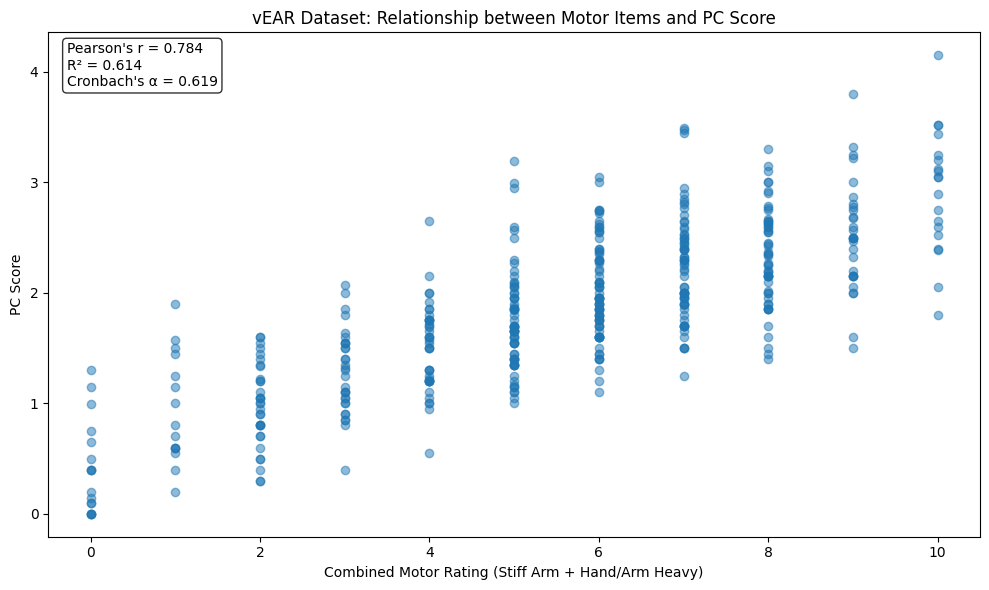


Detailed Statistics:
Pearson's r: 0.7835
R-squared: 0.6139
Cronbach's alpha: 0.6190


In [22]:
# Load the vEAR and PC dataset
df5 = pd.read_csv('vEAR and PC data.csv')

# Calculate the sum of motor challenge ratings
df5['CombinedMotorRating'] = df5['StiffArm'] + df5['HandAndArmHeavy']

# Calculate correlation using pingouin
correlation = pg.corr(df5['CombinedMotorRating'], 
                     df5['PCscore'],
                     method='pearson')

# Extract r and calculate r-squared
pearson_r = correlation['r'].values[0]
r_squared = pearson_r**2

# Calculate Cronbach's alpha
items = df5[['StiffArm', 'HandAndArmHeavy']]
alpha = pg.cronbach_alpha(items)
cronbach_alpha = alpha[0]  # Extract just the alpha value

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
plt.scatter(df5['CombinedMotorRating'], df5['PCscore'], alpha=0.5)
plt.xlabel('Combined Motor Rating (Stiff Arm + Hand/Arm Heavy)')
plt.ylabel('PC Score')
plt.title('vEAR Dataset: Relationship between Motor Items and PC Score')


# Add summary statistics to plot
stats_text = f"Pearson's r = {pearson_r:.3f}\n"
stats_text += f"R² = {r_squared:.3f}\n"
stats_text += f"Cronbach's α = {cronbach_alpha:.3f}"

# Position the text in the upper left corner
plt.text(0.02, 0.98, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\nDetailed Statistics:")
print(f"Pearson's r: {pearson_r:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Cronbach's alpha: {cronbach_alpha:.4f}")